In [2]:
from sqlglot.optimizer.scope import build_scope
from sqlglot import parse_one
from sqlglot.optimizer.qualify import qualify
from sqlglot.lineage import lineage, GraphHTML
from sqlglot import exp
from lineage import LineageMap

sql = """
WITH cleaned_orders AS (
    SELECT
        o.order_id,
        o.customer_id,
        CAST(o.order_ts AS DATE) AS order_date,
        COALESCE(o.amount, 0) AS amount,
        o.status AS order_status
    FROM db.raw_orders o
    WHERE o.order_ts IS NOT NULL
),

valid_orders AS (
    SELECT
        order_id,
        customer_id,
        order_date,
        amount,
        order_status
    FROM cleaned_orders
    WHERE order_status IN ('paid', 'shipped', 'completed')
),

orders_with_payments AS (
    SELECT
        vo.order_id,
        vo.customer_id,
        vo.order_date,
        vo.amount,
        p.payment_status
    FROM valid_orders vo
    LEFT JOIN raw_payments p
        ON vo.order_id = p.order_id
),

paid_orders AS (
    SELECT
        order_id,
        customer_id,
        order_date,
        amount
    FROM orders_with_payments
    WHERE payment_status = 'success'
),

customer_aggregates AS (
    SELECT
        po.customer_id,
        COUNT(po.order_id) AS total_orders,
        SUM(po.amount) AS total_revenue,
        AVG(po.amount) AS avg_order_value,
        MIN(po.order_date) AS first_order_date,
        MAX(po.order_date) AS last_order_date
    FROM paid_orders po
    GROUP BY po.customer_id
),

customer_enriched AS (
    SELECT
        c.customer_id,
        c.customer_name,
        c.country,
        c.signup_date,
        ca.total_orders,
        ca.total_revenue,
        ca.avg_order_value,
        ca.first_order_date,
        ca.last_order_date,
        (CURRENT_DATE - ca.last_order_date) AS days_since_last_order
    FROM raw_customers c
    LEFT JOIN customer_aggregates ca
        ON c.customer_id = ca.customer_id
),

customer_segmented AS (
    SELECT
        ce.customer_id,
        ce.customer_name,
        ce.country,
        ce.signup_date,
        COALESCE(ce.total_orders, 0) AS total_orders,
        COALESCE(ce.total_revenue, 0) AS total_revenue,
        ce.avg_order_value,
        ce.first_order_date,
        ce.last_order_date,
        ce.days_since_last_order,
        CASE
            WHEN ce.total_revenue >= 10000 THEN 'VIP'
            WHEN ce.days_since_last_order > 180 THEN 'Churn Risk'
            WHEN ce.total_orders >= 5 THEN 'Regular'
            ELSE 'New'
        END AS customer_segment
    FROM customer_enriched ce
)

SELECT
        cs.customer_id,
    cs.customer_name,
    cs.country,
    cs.signup_date,
FROM customer_segmented cs
"""

sql2 = """
CREATE TABLE persons (
    PersonID INT PRIMARY KEY,
    LastName VARCHAR(255) NOT NULL,
    FirstName VARCHAR(255),
    Address VARCHAR(255),
    City VARCHAR(255));
"""

sql3 = """
CREATE TABLE db.raw_orders (
    order_id INT PRIMARY KEY,
    customer_id INT NOT NULL REFERENCES persons(PersonID),
    OrderDate DATE NOT NULL,
    Quantity INT NOT NULL);
"""

sql4 = """
SELECT employee_id, name, salary, department
FROM (
    SELECT employee_id, name, salary, department
    FROM (
        -- Level 3 (innermost): base filter
        SELECT employee_id, name, salary, department
        FROM employees
        WHERE salary > 50000
    ) AS high_paid
    -- Level 2: compare against aggregate from another subquery
    WHERE salary < (
        SELECT AVG(salary)
        FROM (
            SELECT salary
            FROM employees
            WHERE salary > 50000
        ) AS avg_base
    )
) AS filtered
-- Level 1 (outermost): final business filter
WHERE department = 'IT';

"""

sql5="""
CREATE TABLE customers(
customer_id int,
first_name varchar(255));
"""
sql6 ="""
SELECT
    ranked_customers.customer_id,
    ranked_customers.first_name,
    ranked_customers.last_name,
    ranked_customers.total_spent
FROM (
    SELECT
        c.customer_id,
        c.first_name,
        c.last_name,
        SUM(o.total_amount) AS total_spent
    FROM customers c
    INNER JOIN orders o
        ON o.customer_id = c.customer_id
    WHERE o.status = 'COMPLETED'
    GROUP BY
        c.customer_id,
        c.first_name,
        c.last_name
) AS ranked_customers
WHERE ranked_customers.total_spent > (
    SELECT AVG(o2.total_amount)
    FROM orders o2
    WHERE o2.status = 'COMPLETED'
)
ORDER BY ranked_customers.total_spent DESC
"""
l = LineageMap()
# l.parse_sql(sql6, file_name="temp1")
l.parse_sql(sql5, file_name="temp2")


Table(customers, columns=[customer_id, first_name])


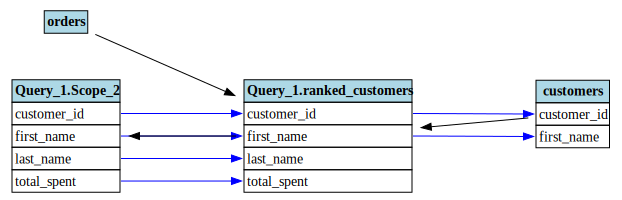

In [2]:
l.visualize()

In [8]:
l._file_node_map['temp2'][0].scope

Table(
  this=Identifier(this=customers, quoted=False))

In [4]:
l.original_scope

In [ ]:
sql6="""
CREATE TABLE employees(
employee_id int,
new_col int,
name int,
salary1 int);
"""
l.parse_sql(sql6)
l.visualize()

In [ ]:
l.table_node_map['employees']

In [ ]:
l.parse_sql(sql4)

In [ ]:
<lineage.TableNode at 0x10c14ee50>